In [1]:
%cd "SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin"
!git pull

/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin
Already up to date.


In [2]:
import jax
print(jax.devices())

[RocmDevice(id=0)]


In [3]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.13.0+cu130
False


In [4]:
import sys
!{sys.executable} -m pip uninstall -y torch torchvision torchaudio
!{sys.executable} -m pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/rocm7.2

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Looking in indexes: https://download.pytorch.org/whl/nightly/rocm7.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 GB 35.0 MB/s  0:01:48m0:00:0100:03
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 GB 19.3 MB/s  0:02:54m0:00:0100:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 361.2/361.2 MB 276.1 MB/s  0:00:010:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 264.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [torchvision] [torchvision]


In [5]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.13.0+cu130
False


In [6]:
%cd "SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin"

[Errno 2] No such file or directory: 'SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin'
/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin


In [7]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.13.0+cu130
False


In [8]:
import sys
print("executable:", sys.executable)
print("---")
for p in sys.path:
    print(p)

executable: /usr/bin/python3
---
/usr/lib/python312.zip
/usr/lib/python3.12
/usr/lib/python3.12/lib-dynload

/usr/local/lib/python3.12/dist-packages
/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin/src
/usr/lib/python3/dist-packages


In [9]:
import torch
print(torch.__version__)
print(torch.__file__)

2.13.0+cu130
/usr/local/lib/python3.12/dist-packages/torch/__init__.py


In [10]:
!find / -name "version.py" -path "*torch/*" 2>/dev/null

/usr/local/lib/python3.12/dist-packages/torch/version.py
/usr/local/lib/python3.12/dist-packages/torch/utils/hipify/version.py
/usr/local/lib/python3.12/dist-packages/torch/_vendor/packaging/version.py


In [11]:
!cat /usr/local/lib/python3.12/dist-packages/torch/version.py

from typing import Optional

__all__ = ['__version__', 'debug', 'cuda', 'git_version', 'hip', 'rocm', 'xpu']
__version__ = '2.14.0.dev20260710+rocm7.2'
debug = False
cuda: Optional[str] = None
git_version = '0ce05af6274d975672dd30447bf00010317288ef'
hip: Optional[str] = '7.2.53211'
rocm: Optional[str] = '7.2.1'
xpu: Optional[str] = None


In [1]:
import jax
print(jax.devices())
print(jax.default_backend())

[RocmDevice(id=0)]
gpu


In [2]:
!apt-get update && apt-get install -y git

Hit:1 https://repo.radeon.com/rocm/apt/7.2.4 noble InRelease
0% [Connecting to security.ubuntu.com]

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease                         
Hit:3 http://security.ubuntu.com/ubuntu noble-security InRelease               
Hit:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
W: https://repo.radeon.com/rocm/apt/7.2.4/dists/noble/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.43.0-1ubuntu7.3).
0 upgraded, 0 newly installed, 0 to remove and 20 not upgraded.


In [3]:
!pip install qarray

In [4]:
import time
from qarray import DotArray

# Default implementation: Rust, CPU. This is the honest non-GPU baseline.
model_cpu = DotArray(
    Cdd=[[0., 0.1], [0.1, 0.]],
    Cgd=[[1., 0.2], [0.2, 1]],
)

t0 = time.time()
n_open_cpu = model_cpu.do2d_open(
    x_gate='P1', x_min=-5, x_max=5, x_res=200,
    y_gate='P2', y_min=-5, y_max=5, y_res=200,
)
t1 = time.time()
print(f"[rust/cpu] Generated {n_open_cpu.shape} diagram in {t1 - t0:.4f}s")

# Explicit JAX implementation: this is the one that should hit the MI300X.
model_jax = DotArray(
    Cdd=[[0., 0.1], [0.1, 0.]],
    Cgd=[[1., 0.2], [0.2, 1]],
    implementation='jax',
)

t0 = time.time()
n_open_jax = model_jax.do2d_open(
    x_gate='P1', x_min=-5, x_max=5, x_res=200,
    y_gate='P2', y_min=-5, y_max=5, y_res=200,
)
t1 = time.time()
print(f"[jax]      Generated {n_open_jax.shape} diagram in {t1 - t0:.4f}s")

[rust/cpu] Generated (200, 200, 2) diagram in 0.0196s
[jax]      Generated (200, 200, 2) diagram in 3.2531s


In [5]:
import time

# Second call, same shapes -- JIT already compiled, this is the "warm" number
t0 = time.time()
n_open_jax_warm = model_jax.do2d_open(
    x_gate='P1', x_min=-5, x_max=5, x_res=200,
    y_gate='P2', y_min=-5, y_max=5, y_res=200,
)
t1 = time.time()
print(f"[jax warm] Generated {n_open_jax_warm.shape} diagram in {t1 - t0:.4f}s")

# A much larger sweep -- where GPU parallelism should start to pay off
t0 = time.time()
n_open_jax_big = model_jax.do2d_open(
    x_gate='P1', x_min=-5, x_max=5, x_res=2000,
    y_gate='P2', y_min=-5, y_max=5, y_res=2000,
)
t1 = time.time()
print(f"[jax big]  Generated {n_open_jax_big.shape} diagram in {t1 - t0:.4f}s")

[jax warm] Generated (200, 200, 2) diagram in 0.0558s
[jax big]  Generated (2000, 2000, 2) diagram in 3.5127s


In [6]:
!git clone https://github.com/k1151msarandega/SimQuantum-AMD-Developer-Hackathon.git

fatal: destination path 'SimQuantum-AMD-Developer-Hackathon' already exists and is not an empty directory.


/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [7]:
%cd "SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin"

/shared-docker/SimQuantum-AMD-Developer-Hackathon/Act II/qdot-live-twin


In [8]:
!pip install -e .

Obtaining file:///shared-docker/SimQuantum-AMD-Developer-Hackathon/Act%20II/qdot-live-twin
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for qdot-twin (pyproject.toml) ... done
  Created wheel for qdot-twin: filename=qdot_twin-0.1.0-0.editable-py3-none-any.whl size=1358 sha256=b49ba25ff3e7aba9f9b09dc76246fbfafd2902cd01c86510db920f3ff18cecb1
  Stored in directory: /tmp/pip-ephem-wheel-cache-fyfl03y0/wheels/fd/f3/6a/ca518160ab5f62866947dcbb641159b0e6ceadb7fc758dd02c
Successfully built qdot-twin
  Attempting uninstall: qdot-twin
    Found existing installation: qdot-twin 0.1.0
    Uninstalling qdot-twin-0.1.0:
      Successfully uninstalled qdot-twin-0.1.0


In [9]:
%run scripts/step2_wiring_check.py

frame    0  estimate cost=0.00501s  (vx=-5.001, vy=-5.005)  predicted_class=1  disagreement=0.053352
frame  100  estimate cost=0.00089s  (vx=-4.490, vy=-4.502)  predicted_class=1  disagreement=0.047369
frame  200  estimate cost=0.00092s  (vx=-3.995, vy=-4.010)  predicted_class=1  disagreement=0.041148
frame  300  estimate cost=0.00089s  (vx=-3.500, vy=-3.496)  predicted_class=1  disagreement=0.034430
frame  400  estimate cost=0.00091s  (vx=-3.006, vy=-2.987)  predicted_class=1  disagreement=0.027554
frame  500  estimate cost=0.00094s  (vx=-2.513, vy=-2.502)  predicted_class=1  disagreement=0.020946
frame  600  estimate cost=0.00095s  (vx=-1.988, vy=-2.004)  predicted_class=1  disagreement=0.014428
frame  700  estimate cost=0.00089s  (vx=-1.490, vy=-1.510)  predicted_class=1  disagreement=0.008921
frame  800  estimate cost=0.00092s  (vx=-0.999, vy=-0.992)  predicted_class=0  disagreement=0.004483
frame  900  estimate cost=0.00087s  (vx=-0.488, vy=-0.496)  predicted_class=0  disagreement

In [10]:
!git pull

/usr/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Already up to date.


In [11]:
!cd qdot-live-twin && git pull && pip install -e .

/bin/bash: line 1: cd: qdot-live-twin: No such file or directory


In [12]:
!pip install -e . 2>&1 | tail -30

  Building editable for qdot-twin (pyproject.toml): started
  Building editable for qdot-twin (pyproject.toml): finished with status 'done'
  Created wheel for qdot-twin: filename=qdot_twin-0.1.0-0.editable-py3-none-any.whl size=1358 sha256=6b1c91dde7e9a6cf3d268c2ad0ee8b1bcc5bcb1bca95458495c5acb58d0cce2d
  Stored in directory: /tmp/pip-ephem-wheel-cache-stsn0la2/wheels/fd/f3/6a/ca518160ab5f62866947dcbb641159b0e6ceadb7fc758dd02c
Successfully built qdot-twin
  Attempting uninstall: qdot-twin
    Found existing installation: qdot-twin 0.1.0
    Uninstalling qdot-twin-0.1.0:
      Successfully uninstalled qdot-twin-0.1.0


In [13]:
import sys
print(sys.executable)

/usr/bin/python3


In [14]:
!which python
!which pip

/usr/bin/python
/usr/local/bin/pip


In [15]:
import sys
!{sys.executable} -m pip install -e .

Obtaining file:///shared-docker/SimQuantum-AMD-Developer-Hackathon/Act%20II/qdot-live-twin
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for qdot-twin (pyproject.toml) ... done
  Created wheel for qdot-twin: filename=qdot_twin-0.1.0-0.editable-py3-none-any.whl size=1358 sha256=c1d81664e4219521e577713056ca9fc116ee74398bc0a433fdd491840336d1b7
  Stored in directory: /tmp/pip-ephem-wheel-cache-c4_t6a5x/wheels/fd/f3/6a/ca518160ab5f62866947dcbb641159b0e6ceadb7fc758dd02c
Successfully built qdot-twin
  Attempting uninstall: qdot-twin
    Found existing installation: qdot-twin 0.1.0
    Uninstalling qdot-twin-0.1.0:
      Successfully uninstalled qdot-twin-0.1.0


In [16]:
%run scripts/step2_wiring_check.py

frame    0  estimate cost=0.03310s  (vx=-4.995, vy=-4.981)  predicted_class=1  disagreement=0.053135
frame  100  estimate cost=0.00091s  (vx=-4.500, vy=-4.493)  predicted_class=1  disagreement=0.047359
frame  200  estimate cost=0.00092s  (vx=-3.996, vy=-4.005)  predicted_class=1  disagreement=0.041110
frame  300  estimate cost=0.00095s  (vx=-3.517, vy=-3.486)  predicted_class=1  disagreement=0.034454
frame  400  estimate cost=0.00090s  (vx=-2.984, vy=-2.977)  predicted_class=1  disagreement=0.027358
frame  500  estimate cost=0.00091s  (vx=-2.507, vy=-2.513)  predicted_class=1  disagreement=0.021008
frame  600  estimate cost=0.00082s  (vx=-1.998, vy=-2.002)  predicted_class=1  disagreement=0.014461
frame  700  estimate cost=0.00092s  (vx=-1.496, vy=-1.513)  predicted_class=1  disagreement=0.008952
frame  800  estimate cost=0.00090s  (vx=-0.983, vy=-1.007)  predicted_class=0  disagreement=0.004506
frame  900  estimate cost=0.00092s  (vx=-0.511, vy=-0.491)  predicted_class=0  disagreement

In [17]:
!git pull

Already up to date.


In [18]:
%run scripts/step2_wiring_check.py

frame    0  estimate cost=0.02679s  (vx=-5.009, vy=-4.995)  predicted_class=1  disagreement=0.053308
frame  100  estimate cost=0.00090s  (vx=-4.502, vy=-4.489)  predicted_class=1  disagreement=0.047335
frame  200  estimate cost=0.00085s  (vx=-4.016, vy=-3.991)  predicted_class=1  disagreement=0.041124
frame  300  estimate cost=0.00096s  (vx=-3.495, vy=-3.501)  predicted_class=1  disagreement=0.034460
frame  400  estimate cost=0.00095s  (vx=-2.993, vy=-3.011)  predicted_class=1  disagreement=0.027698
frame  500  estimate cost=0.00091s  (vx=-2.487, vy=-2.505)  predicted_class=1  disagreement=0.020838
frame  600  estimate cost=0.00091s  (vx=-1.999, vy=-2.020)  predicted_class=1  disagreement=0.014593
frame  700  estimate cost=0.00089s  (vx=-1.507, vy=-1.498)  predicted_class=1  disagreement=0.008899
frame  800  estimate cost=0.00095s  (vx=-0.973, vy=-0.991)  predicted_class=0  disagreement=0.004413
frame  900  estimate cost=0.00084s  (vx=-0.494, vy=-0.494)  predicted_class=0  disagreement

In [19]:
!git pull

Already up to date.


In [20]:
%run scripts/step2_wiring_check.py

frame    0  estimate cost=0.04080s  (vx=-5.011, vy=-4.994)  predicted_class=1  disagreement=0.053301
frame  100  estimate cost=0.00086s  (vx=-4.511, vy=-4.500)  predicted_class=1  disagreement=0.047458
frame  200  estimate cost=0.00083s  (vx=-3.999, vy=-4.000)  predicted_class=1  disagreement=0.041095
frame  300  estimate cost=0.00089s  (vx=-3.504, vy=-3.497)  predicted_class=1  disagreement=0.034461
frame  400  estimate cost=0.00097s  (vx=-3.000, vy=-2.988)  predicted_class=1  disagreement=0.027523
frame  500  estimate cost=0.00090s  (vx=-2.504, vy=-2.496)  predicted_class=1  disagreement=0.020840
frame  600  estimate cost=0.00090s  (vx=-1.990, vy=-2.014)  predicted_class=1  disagreement=0.014504
frame  700  estimate cost=0.00082s  (vx=-1.503, vy=-1.486)  predicted_class=1  disagreement=0.008826
frame  800  estimate cost=0.00089s  (vx=-0.990, vy=-1.003)  predicted_class=0  disagreement=0.004510
frame  900  estimate cost=0.00086s  (vx=-0.518, vy=-0.508)  predicted_class=0  disagreement

frame    0  lag=0.0013s  run elapsed=0.2s
frame  200  lag=0.0010s  run elapsed=16.8s
frame  400  lag=0.0010s  run elapsed=23.1s
frame  600  lag=0.0009s  run elapsed=27.2s
frame  800  lag=0.0009s  run elapsed=30.3s
frame 1000  lag=0.0009s  run elapsed=33.2s
frame 1200  lag=0.0017s  run elapsed=36.5s
frame 1400  lag=0.0064s  run elapsed=39.4s
frame 1600  lag=0.0009s  run elapsed=42.4s
frame 1800  lag=0.0009s  run elapsed=45.1s

Saved 2000 rows to scripts/serial_baseline_staleness.csv
lag: min=0.0006s max=0.0808s mean=0.0018s
Saved plot to scripts/serial_baseline_staleness.png


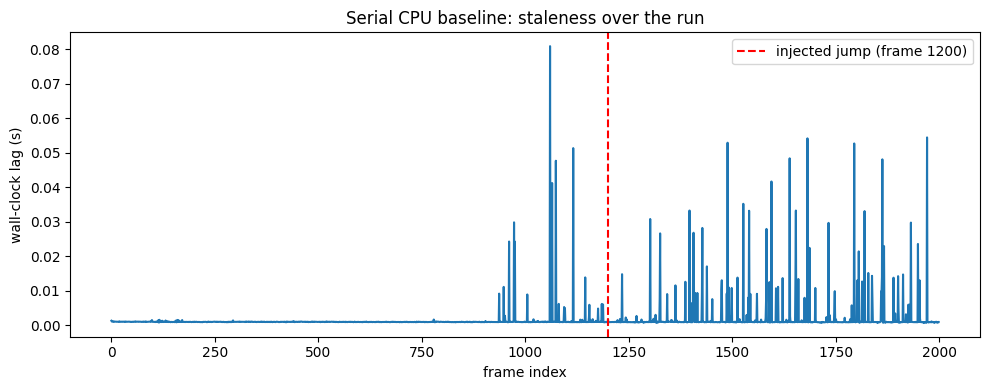

In [21]:
%run scripts/run_serial_baseline.py